# Chua's Circuit: part 3
We will try using a better dataset with more data points, as the electric circuit is easily measurable

In [2]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

# Dataset

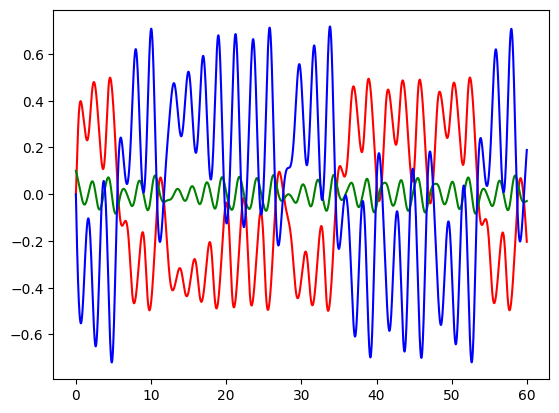

In [3]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])

T_MAX = 60

term = dfx.ODETerm(chua_model)
solver = dfx.Dopri5()
y0 = jnp.array((0.0001, 0.1, 0))
saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.01))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat)

plt.plot(sol.ts, sol.ys[:, 0], color='r')
plt.plot(sol.ts, sol.ys[:, 1], color='g')
plt.plot(sol.ts, sol.ys[:, 2], color='b')


In [4]:
T_MAX = 750

@eqx.filter_jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 1/2))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                                max_steps=4096*2*2*2*2*2*2*2*2*2)

    x_train = sol_train.ys[::1]
    t_train = sol_train.ts[::1]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 1/2))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                              max_steps=4096*2*2*2*2*2*2*2*2*2)

    x_val = sol_val.ys[::1]
    t_val = sol_val.ts[::1]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [5]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


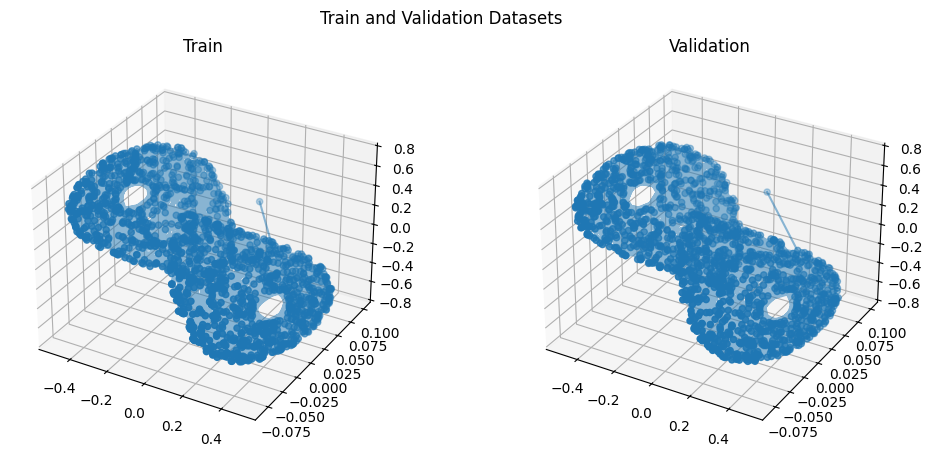

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(projection='3d'))

axes[0].plot(sol_train.ys[:, 0],sol_train.ys[:, 1],sol_train.ys[:, 2],alpha=0.5)
axes[0].scatter(x_train[:, 0],x_train[:, 1],x_train[:, 2],)

axes[1].plot(sol_val.ys[:, 0],sol_val.ys[:, 1],sol_val.ys[:, 2], alpha=0.5)
axes[1].scatter(x_val[:, 0],x_val[:, 1],x_val[:, 2],)

axes[0].set_title("Train")
axes[1].set_title("Validation")

plt.suptitle("Train and Validation Datasets")

plt.show()

In [7]:
x_train.shape

(1500, 3)

# Model
We use the UDE PEM x

In [8]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [9]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [10]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def __call__(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)


In [11]:
# Load model if needed
#N.B. ude_pem is not a UDE PEM anymore but just a regular UDE
key = jr.PRNGKey(0)
ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

ude_pem = eqx.tree_deserialise_leaves("./models_weights/31_5_ude_jax_big_dataset_dthalf.eqx", ude_pem)

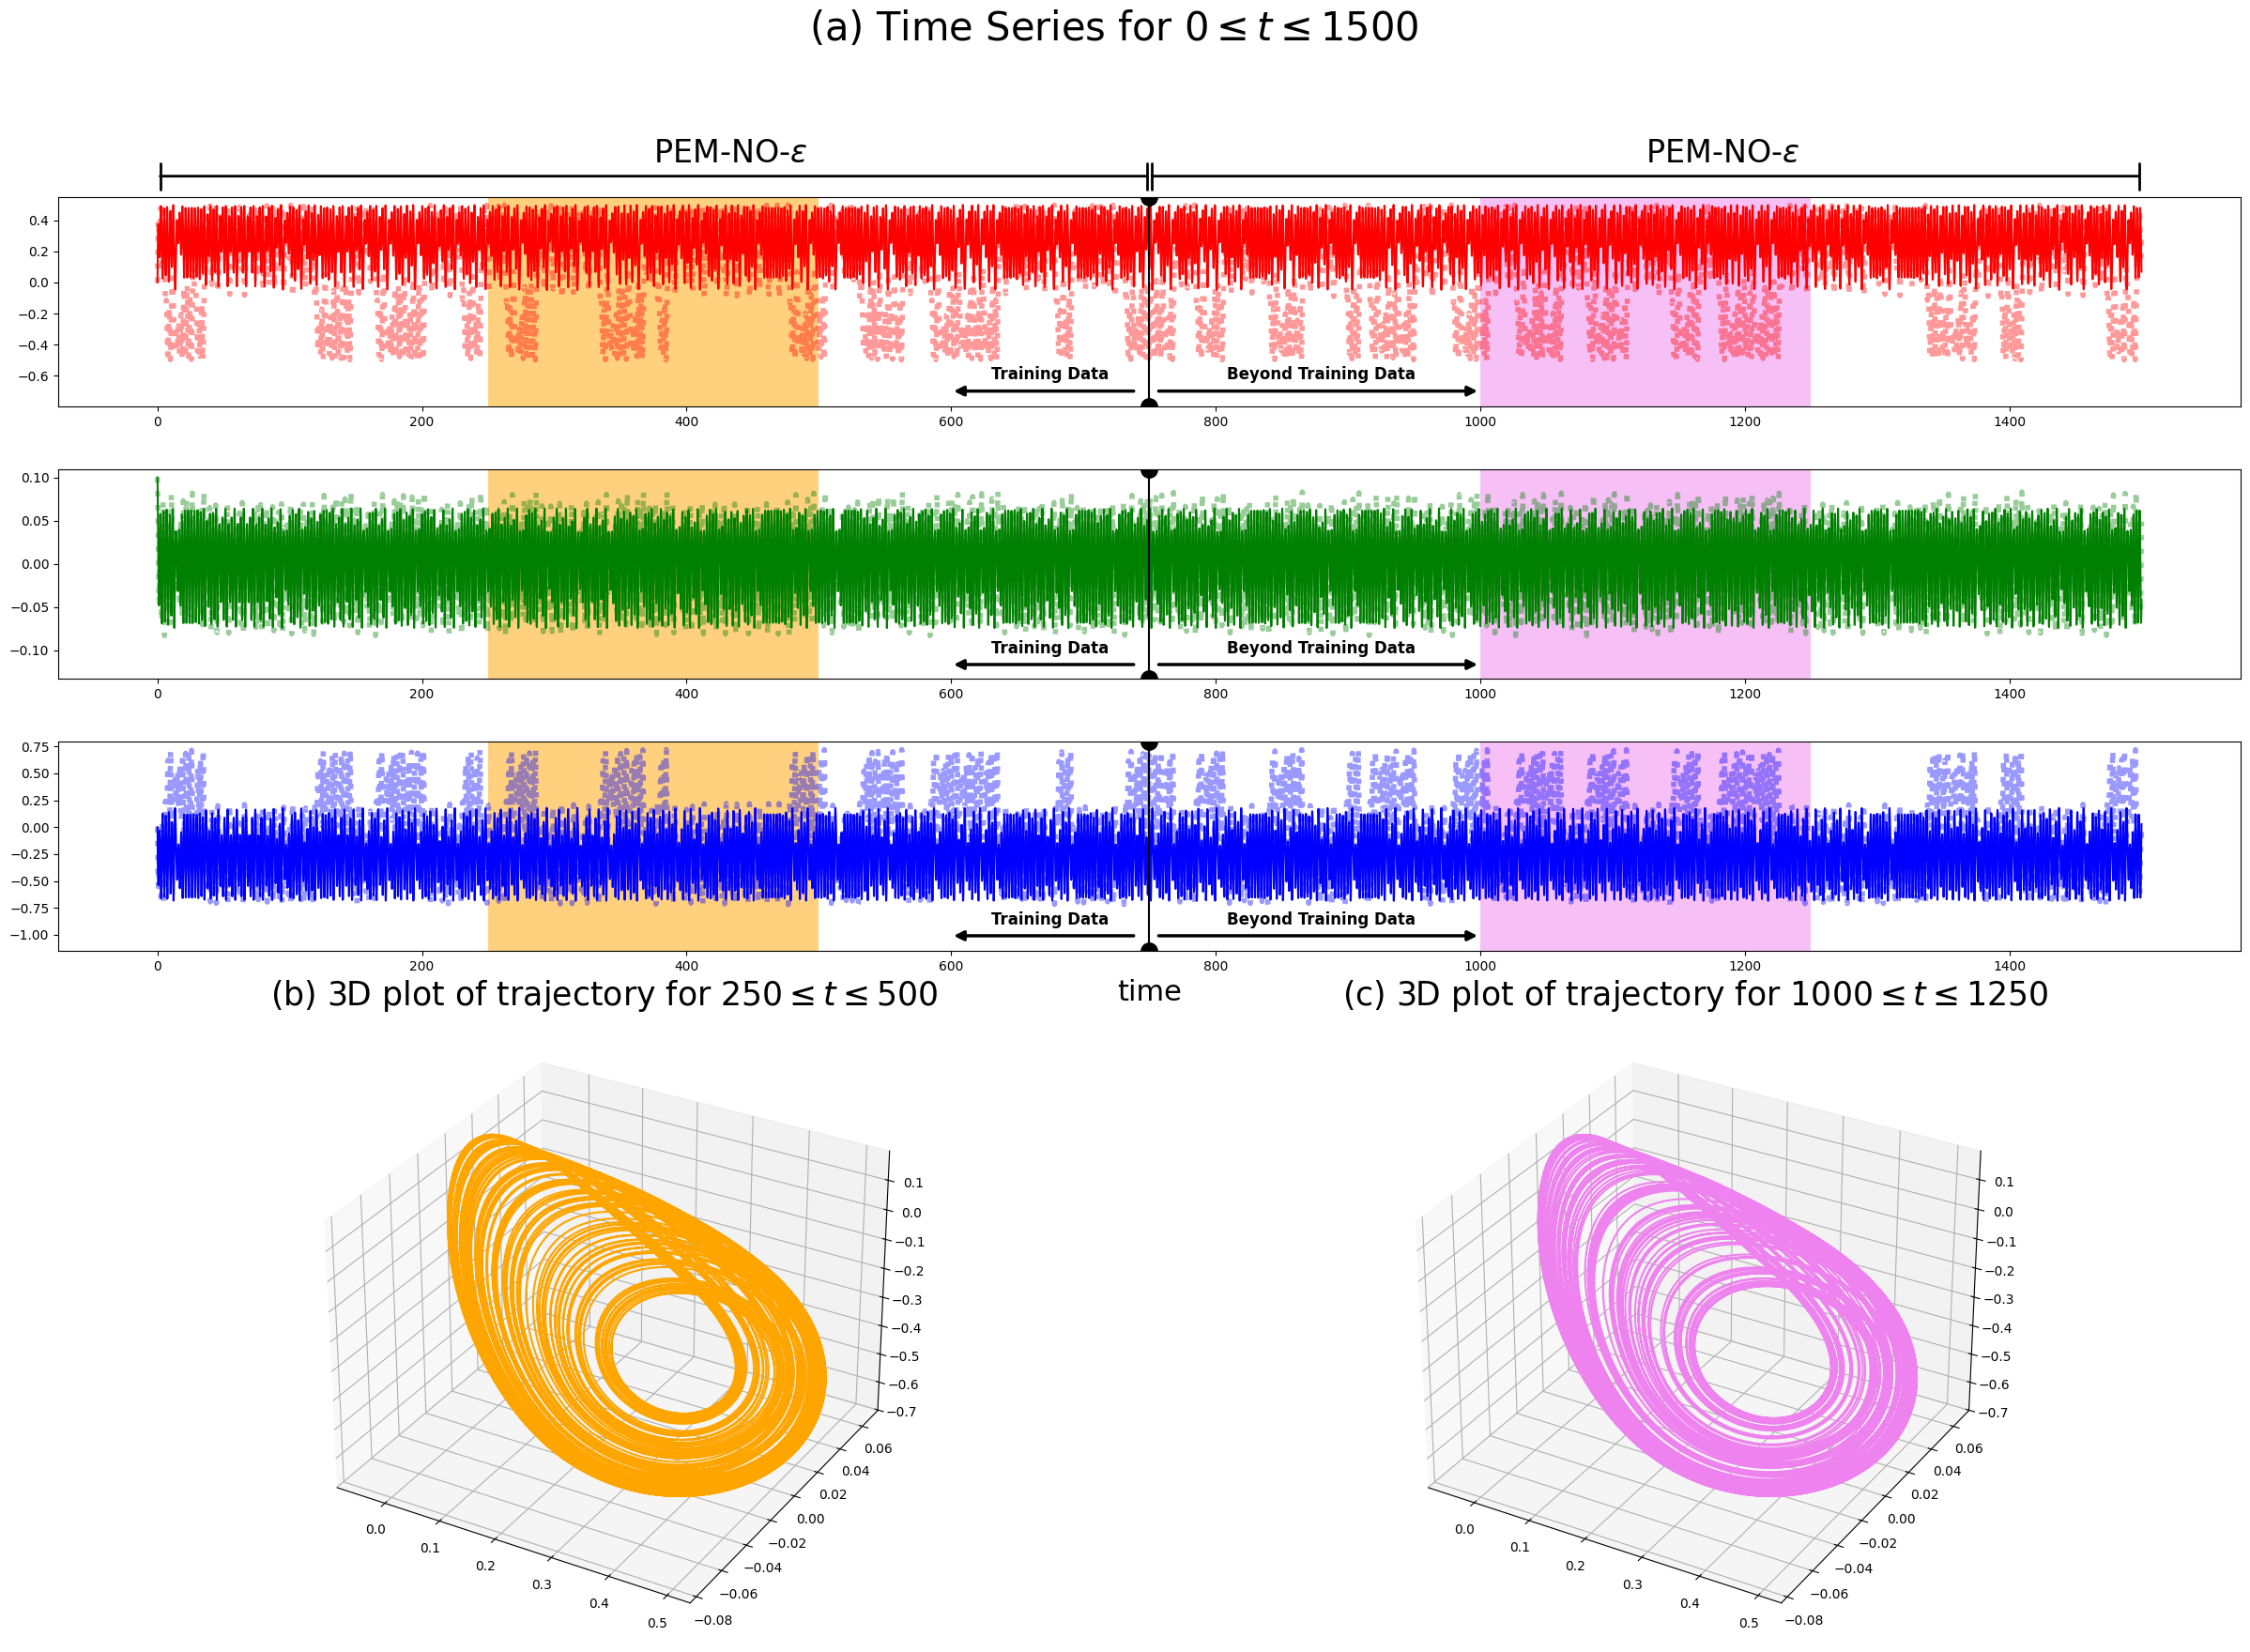

In [14]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 1500

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set

mosaic = [
    [ 0, 0],
    [ 1, 1,],
    [ 2, 2,],
    [ '3dplot_1', '3dplot_2']
]

fig, axes = plt.subplot_mosaic(mosaic=mosaic, figsize=(30, 20), 
                               per_subplot_kw={'3dplot_1': {'projection': '3d'}, 
                                               '3dplot_2': {'projection': '3d'}},
                                               gridspec_kw={'height_ratios': [1, 1, 1, 3], 'wspace':0}
)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.00001, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper, 
                      max_steps=4096*2*2*2*2*2)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.00001, y0=y0, saveat=saveat, stepsize_controller=stepper, 
                             max_steps=4096*2*2*2*2*2*2*2,
                             ).ys

plt.sca(axes[0])
plt.suptitle("(a) Time Series for $0 \\leq t \\leq 1500$", size=30)

for i in range(3):
    plt.sca(axes[i])
    axes[i].plot(t_eval, traj_final[:, i], color=col_dict[i],)
    axes[i].plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=4, alpha=0.4)
    plt.axvline(t_train[-1], color="k", label="Last Training Set Point", marker=".", markersize=25)

    y_min = min(jnp.min(traj_true[:, i]), jnp.min(traj_final[:, i]))
    y_max = max(jnp.max(traj_true[:, i]), jnp.max(traj_final[:, i]))
    plt.ylim(y_min * 1.6, None)

    if i==0:
        trans = axes[i].get_xaxis_transform()
        plt.annotate(
            "",
            xy=(0, 1.1),
            xytext=(750, 1.1),
            xycoords=trans,
            textcoords=trans,
            arrowprops=dict(
                arrowstyle="|-|",
                lw=2,
                color="k"
            ),
            annotation_clip=False
        )

        trans = axes[i].get_xaxis_transform()
        plt.annotate(
            "",
            xy=(750, 1.1),
            xytext=(1500, 1.1),
            xycoords=trans,
            textcoords=trans,
            arrowprops=dict(
                arrowstyle="|-|",
                lw=2,
                color="k"
            ),
            annotation_clip=False
        )

        plt.text(0.5*(0 + 750), y_max*1.55, r"PEM-NO-$\varepsilon$", size=24)
        plt.text(0.5*(750 + 1500), y_max*1.55, r"PEM-NO-$\varepsilon$", size=24)

    plt.annotate('', xy=(1000, y_min+y_min*0.4), xytext=(755, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(1000+760), y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold",size=12)
# 
    plt.annotate('', xy=(740, y_min+y_min*0.4), xytext=(600, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(740+600+10), y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold", size=12 )

    plt.axvspan(250, 500, lw=0, color='orange', alpha=0.5)
    plt.axvspan(1000, 1250, lw=0, color='violet', alpha=0.5)

plt.xlabel("time", size=22)

plt.sca(axes['3dplot_1'])
plt.title("(b) 3D plot of trajectory for $250 \\leq t \\leq 500$", size=25)

plt.sca(axes['3dplot_2'])
plt.title("(c) 3D plot of trajectory for $1000 \\leq t \\leq 1250$", size=25)

axes['3dplot_1'].plot(traj_final[250*100:500*100, 0],traj_final[250*100:500*100, 1],traj_final[250*100:500*100, 2],alpha=1, color='orange')
axes['3dplot_2'].plot(traj_final[1000*100:1250*100, 0],traj_final[1000*100:1250*100, 1],traj_final[1000*100:1250*100, 2], alpha=1, color='violet')

plt.show()
